In [114]:
from network import *
%run network

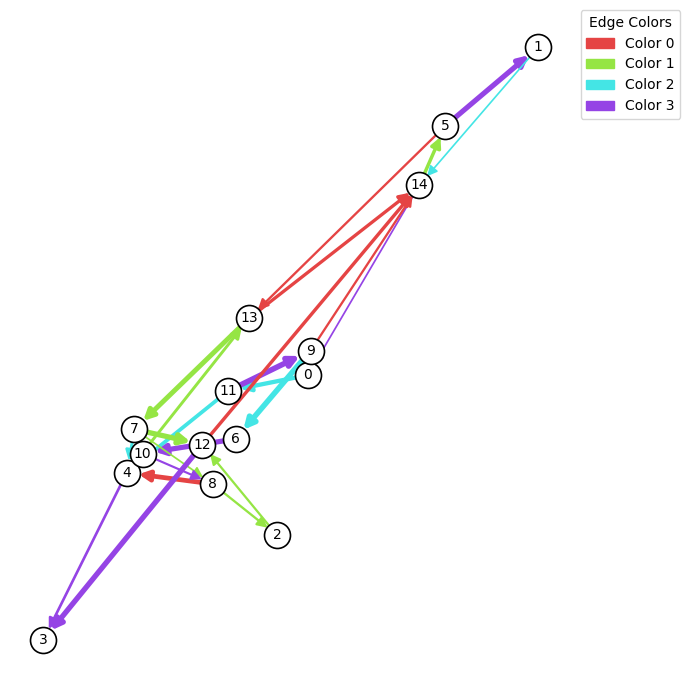

In [115]:
n1 = SupplyChainNetwork.generate(num_nodes=15, num_edges=25, num_colors=4)
n1.visualize_supply_chain()

Number of subnetworks: 45


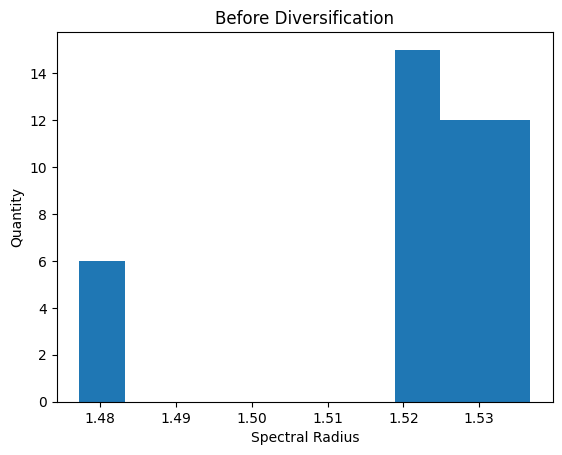

Percentage of subnetworks with spectral radius >= 1: 1.0


In [195]:
%run network
n1 = SupplyChainNetwork.generate(num_nodes=25, num_edges=40, num_colors=4)
print("Number of subnetworks:", len(n1.subnetworks))
subnetwork_radii = [np.abs(eigs(nx.adjacency_matrix(G), k=1, which="LM")[0][0]) for G in n1.subnetworks]

plt.hist(subnetwork_radii)

plt.xlabel("Spectral Radius")
plt.ylabel("Quantity")
plt.title("Before Diversification")
plt.show()

print("Percentage of subnetworks with spectral radius >= 1:", sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii))

Number of subnetworks: 114


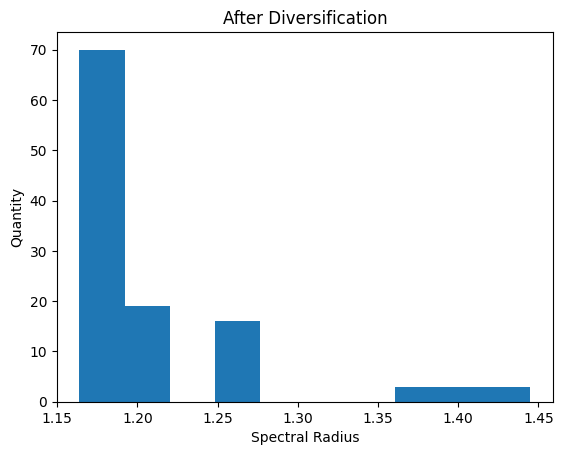

Percentage of subnetworks with spectral radius >= 1: 1.0


In [185]:
n1.diversify(1/3)
n1._subnetworks = n1.calculate_subnetworks()
print("Number of subnetworks:", len(n1.subnetworks))
subnetwork_radii = [np.abs(eigs(nx.adjacency_matrix(G), k=1, which="LM")[0][0]) for G in n1.subnetworks]

plt.hist(subnetwork_radii)

plt.xlabel("Spectral Radius")
plt.ylabel("Quantity")
plt.title("After Diversification")
plt.show()

print("Percentage of subnetworks with spectral radius >= 1:", sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii))

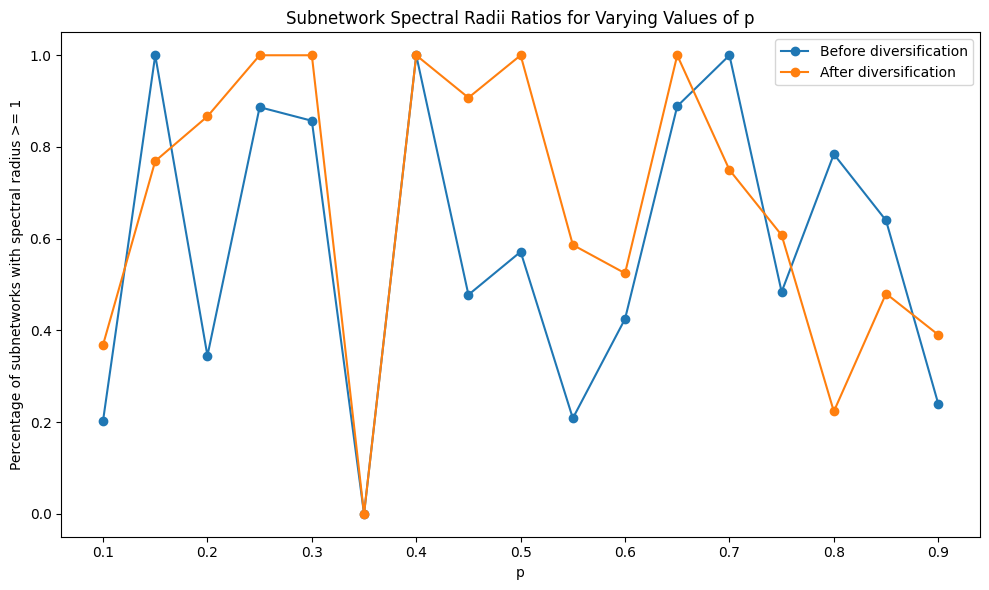

In [ ]:
lam_vals = np.linspace(0.1, 0.9, 17)
subnetwork_ratios_original = []
subnetwork_ratios_diversified = []

for lam in lam_vals:
    n1 = SupplyChainNetwork.generate(num_nodes=25, num_edges=40, num_colors=4)
    subnetwork_radii = [np.abs(eigs(nx.adjacency_matrix(G), k=1, which="LM")[0][0]) for G in n1.subnetworks]
    ratio = sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii)
    subnetwork_ratios_original.append(ratio)

    n1.diversify(lam)
    subnetwork_radii = [np.abs(eigs(nx.adjacency_matrix(G), k=1, which="LM")[0][0]) for G in n1.subnetworks]
    ratio = sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii)
    subnetwork_ratios_diversified.append(ratio)

plt.figure(figsize=(10, 6))
plt.plot(lam_vals, subnetwork_ratios_original, 'o-', label="Before diversification")
plt.plot(lam_vals, subnetwork_ratios_diversified, 'o-', label="After diversification")
plt.xlabel("p")
plt.ylabel("Percentage of subnetworks with spectral radius >= 1")
plt.title("Subnetwork Spectral Radii Ratios for Varying Values of p")
plt.legend()

plt.tight_layout()
plt.show()

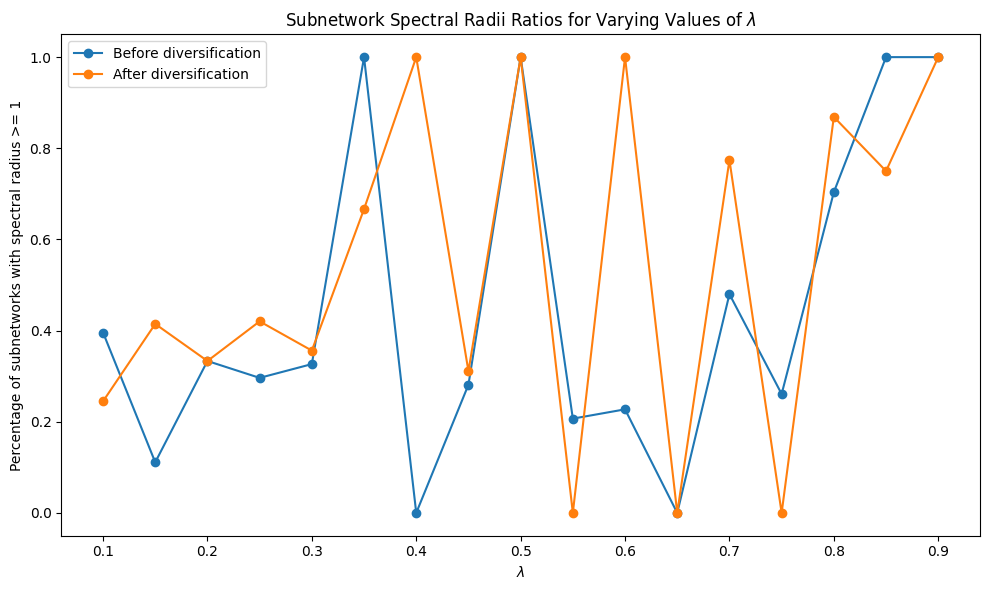

In [199]:
lam_vals = np.linspace(0.1, 0.9, 17)
subnetwork_ratios_original = []
subnetwork_ratios_diversified = []

for lam in lam_vals:
    n1 = SupplyChainNetwork.generate(num_nodes=25, num_edges=40, num_colors=4)
    subnetwork_radii = [np.abs(eigs(nx.adjacency_matrix(G), k=1, which="LM")[0][0]) for G in n1.subnetworks]
    ratio = sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii)
    subnetwork_ratios_original.append(ratio)

    n1.diversify(p=0.25, lam=lam)
    subnetwork_radii = [np.abs(eigs(nx.adjacency_matrix(G), k=1, which="LM")[0][0]) for G in n1.subnetworks]
    ratio = sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii)
    subnetwork_ratios_diversified.append(ratio)

plt.figure(figsize=(10, 6))
plt.plot(lam_vals, subnetwork_ratios_original, 'o-', label="Before diversification")
plt.plot(lam_vals, subnetwork_ratios_diversified, 'o-', label="After diversification")
plt.xlabel(r"$\lambda$")
plt.ylabel("Percentage of subnetworks with spectral radius >= 1")
plt.title(r"Subnetwork Spectral Radii Ratios for Varying Values of $\lambda$")
plt.legend()

plt.tight_layout()
plt.show()